In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


#Loading Dataset`

In [2]:
df = pd.read_csv("video_games_clean_sample.csv")

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,SSX 3,GC,2003.0,Sports,Electronic Arts,0.29,0.08,0.00,0.01,0.38,92.0,27.0,8.7,45.0,EA Canada,E
1,Valhalla Knights 2,PSP,2008.0,Role-Playing,Rising Star Games,0.09,0.00,0.12,0.01,0.23,50.0,13.0,5.4,13.0,K2,E10+
2,Battlefield 4,PS4,2013.0,Shooter,Electronic Arts,1.35,1.55,0.17,0.51,3.59,85.0,18.0,6.9,1580.0,EA DICE,M
3,NBA 2K14,XOne,2013.0,Sports,Take-Two Interactive,0.70,0.11,0.00,0.09,0.91,86.0,15.0,5.7,183.0,Visual Concepts,E
4,Resident Evil: Survivor,PS,2000.0,Action,Eidos Interactive,0.23,0.15,0.29,0.05,0.71,39.0,10.0,7.0,47.0,Capcom,M


#Displaying descriptive statistics


In [4]:
df.shape #checking shape of df rows , cols\
df.describe() # check basic statistics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             1500 non-null   object 
 1   Platform         1500 non-null   object 
 2   Year_of_Release  1467 non-null   float64
 3   Genre            1500 non-null   object 
 4   Publisher        1500 non-null   object 
 5   NA_Sales         1500 non-null   float64
 6   EU_Sales         1500 non-null   float64
 7   JP_Sales         1500 non-null   float64
 8   Other_Sales      1500 non-null   float64
 9   Global_Sales     1500 non-null   float64
 10  Critic_Score     1500 non-null   float64
 11  Critic_Count     1500 non-null   float64
 12  User_Score       1500 non-null   float64
 13  User_Count       1500 non-null   float64
 14  Developer        1499 non-null   object 
 15  Rating           1485 non-null   object 
dtypes: float64(10), object(6)
memory usage: 187.6+ KB


#Dropping Text features

In [5]:
df.drop(columns = ['Developer' , 'Name','Publisher', 'Rating'] , axis=1 , inplace = True)

##Year of release feature is In 2026 form so we could get it down as game age to make sure the large number doesnt bias the model

In [6]:
df["Game_Age"] = 2026 - df["Year_of_Release"]
df.drop(columns=["Year_of_Release"], inplace=True, axis=1)

#Dropping all sales exceot gobal sales to prevent data leakege

In [7]:
#df.drop(columns=["NA_Sales","EU_Sales","JP_Sales","Other_Sales"],axis=1,inplace=True)

##

##Genre is a text feature we cant make anything from it but it has only 12 unique values so we could encode it to benefit from it

In [8]:
df[["Genre"]].nunique() # number of unique values in genre and platform makes us able to encode them to benefit from them

,0
Genre,12


##Encoding Genre using 1 hot encoder to be able to extract insights from it

In [9]:
df = pd.get_dummies(df, columns=["Genre"], drop_first=True)

##Also we see that Platform is a text but has only 17 unique values we can encode them to be able to use them

In [10]:
df['Platform'].nunique()

17

In [11]:
df = pd.get_dummies(df, columns=["Platform"], drop_first=True)

In [12]:
df.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Game_Age,...,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,0.29,0.08,0.00,0.01,0.38,92.0,27.0,8.7,45.0,23.0,...,False,False,False,False,False,False,False,False,False,False
1,0.09,0.00,0.12,0.01,0.23,50.0,13.0,5.4,13.0,18.0,...,False,False,False,True,False,False,False,False,False,False
2,1.35,1.55,0.17,0.51,3.59,85.0,18.0,6.9,1580.0,13.0,...,False,False,True,False,False,False,False,False,False,False
3,0.70,0.11,0.00,0.09,0.91,86.0,15.0,5.7,183.0,13.0,...,False,False,False,False,False,False,False,False,False,True
4,0.23,0.15,0.29,0.05,0.71,39.0,10.0,7.0,47.0,26.0,...,False,False,False,False,False,False,False,False,False,False


##Checking for and Dealing with NaNs

In [13]:
df.isna().sum()

,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0
Critic_Score,0
Critic_Count,0
User_Score,0
User_Count,0
Game_Age,33


##We see only game age is missing 30 values so we will use the median then convert the result to int as it must be a whol number

In [14]:
median_age = df["Game_Age"].median()

df["Game_Age"] = df["Game_Age"].fillna(median_age).astype(int)

##Checking and dealing with incorrect datatype

In [15]:
df.dtypes

,0
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64
Critic_Score,float64
Critic_Count,float64
User_Score,float64
User_Count,float64
Game_Age,int64


##All the encoded features are boolean we will switch them to int 1/0 for easier computation

In [16]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

#df.dtypes to check

In [17]:
df.dtypes

,0
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64
Critic_Score,float64
Critic_Count,float64
User_Score,float64
User_Count,float64
Game_Age,int64


##Outlier handling

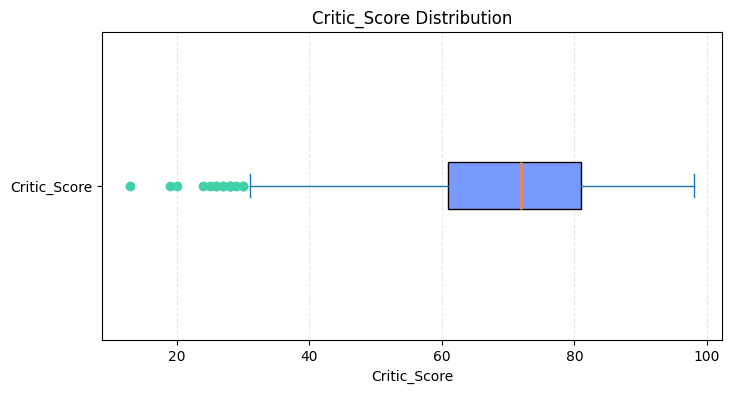

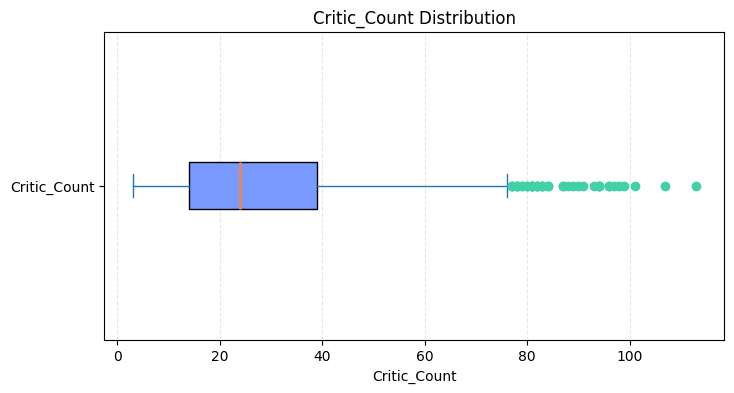

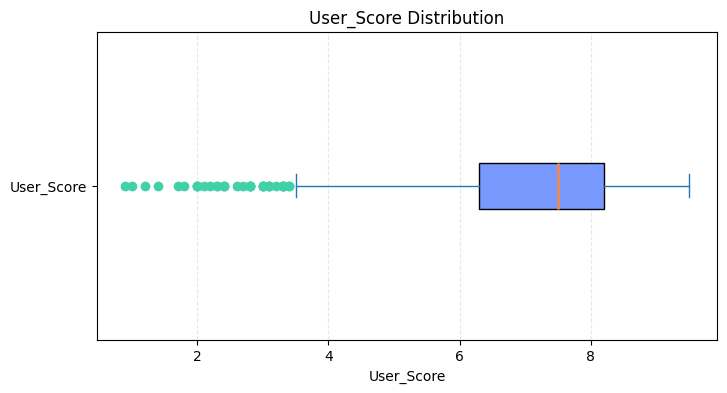

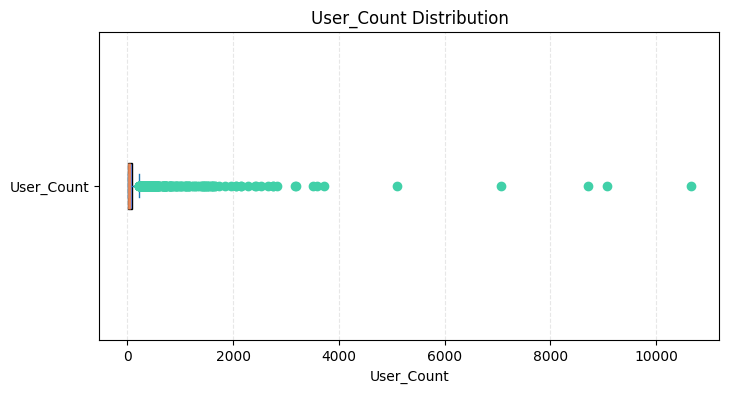

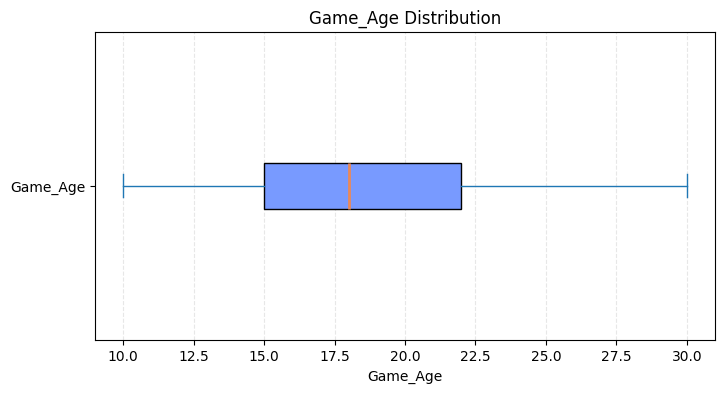

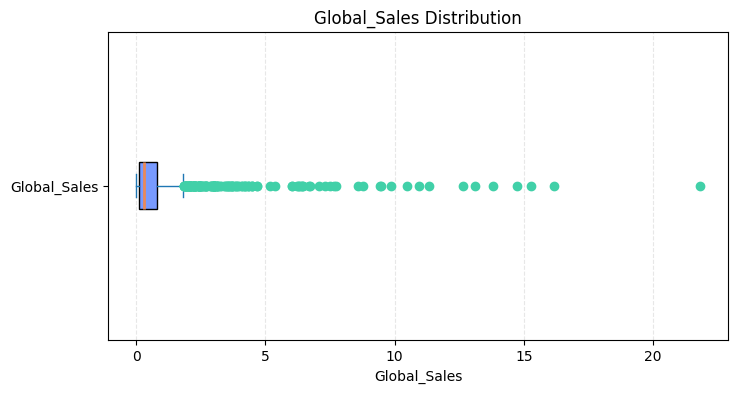

In [18]:
cols_to_check = [
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Game_Age",
    "Global_Sales"
]

for col in cols_to_check:
    if col in df.columns:

        df[col].plot(
            kind='box',
            title=f'{col} Distribution',
            vert=False,
            figsize=(8, 4),
            patch_artist=True,
            boxprops=dict(facecolor='#789AFF'),
            medianprops=dict(color='#EA8958', linewidth=2),
            flierprops=dict(marker='o', markersize=6,
                            markerfacecolor='#41D0A8',
                            markeredgecolor='#41D0A8')
        )

        plt.xlabel(col)
        plt.grid(axis='x', linestyle='--', alpha=0.3)
        plt.show()

#Dealing with outlier 1 Critic_score

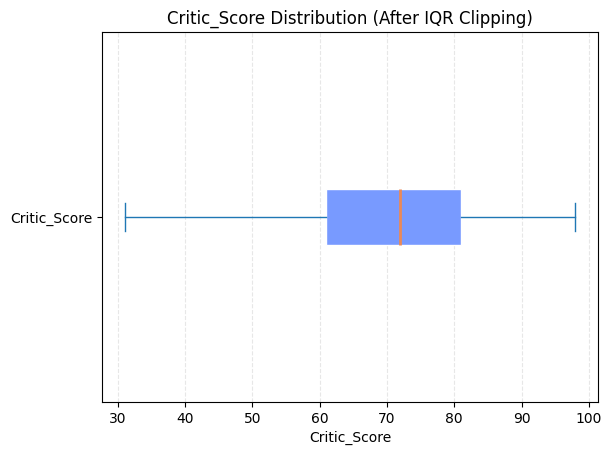

In [19]:

# make a copy so original data is preserved
df_clip = df.copy()

# ---- IQR CLIPPING ----
Q1 = df_clip['Critic_Score'].quantile(0.25)
Q3 = df_clip['Critic_Score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['Critic_Score'] = df_clip['Critic_Score'].clip(lower=lower, upper=upper)

# ---- PLOT AFTER CLIPPING ----
df_clip['Critic_Score'].plot(
    kind='box',
    title='Critic_Score Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('Critic_Score')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

#Dealing with outlier 2 Critic Count


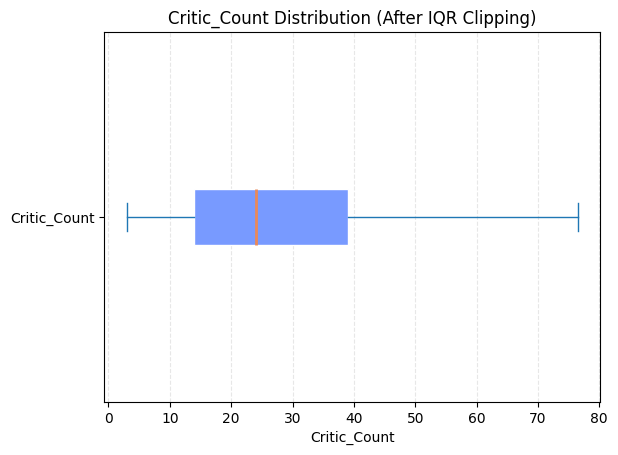

In [20]:


# ---- IQR CLIPPING ----
Q1 = df_clip['Critic_Count'].quantile(0.25)
Q3 = df_clip['Critic_Count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['Critic_Count'] = df_clip['Critic_Count'].clip(lower=lower, upper=upper)

# ---- PLOT AFTER CLIPPING ----
df_clip['Critic_Count'].plot(
    kind='box',
    title='Critic_Count Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('Critic_Count')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

#Dealing with Outlier 3 User score

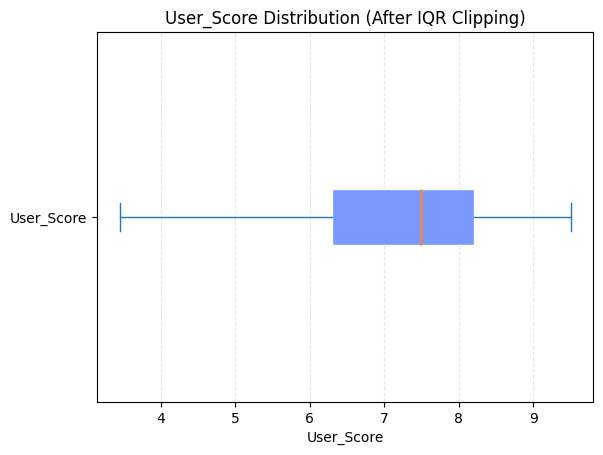

In [21]:


# ---- IQR CLIPPING ----
Q1 = df_clip['User_Score'].quantile(0.25)
Q3 = df_clip['User_Score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['User_Score'] = df_clip['User_Score'].clip(lower=lower, upper=upper)

# ---- PLOT AFTER CLIPPING ----
df_clip['User_Score'].plot(
    kind='box',
    title='User_Score Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('User_Score')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

#Dealing with outlier 4 User count

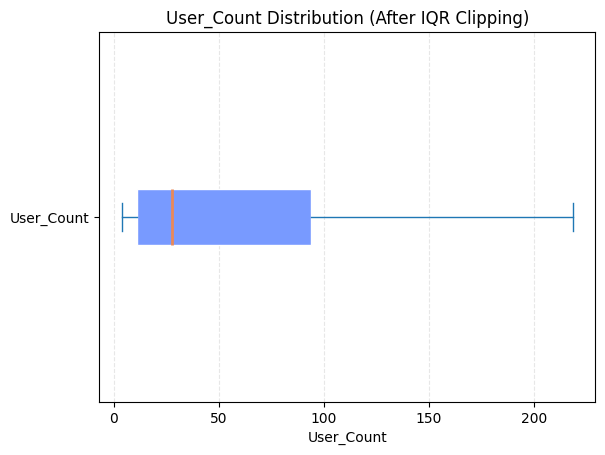

In [22]:


# ---- IQR CLIPPING ----
Q1 = df_clip['User_Count'].quantile(0.25)
Q3 = df_clip['User_Count'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['User_Count'] = df_clip['User_Count'].clip(lower=lower, upper=upper)

# ---- PLOT AFTER CLIPPING ----
df_clip['User_Count'].plot(
    kind='box',
    title='User_Count Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('User_Count')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

##Dealing with outlier 5 global sales

> Add blockquote



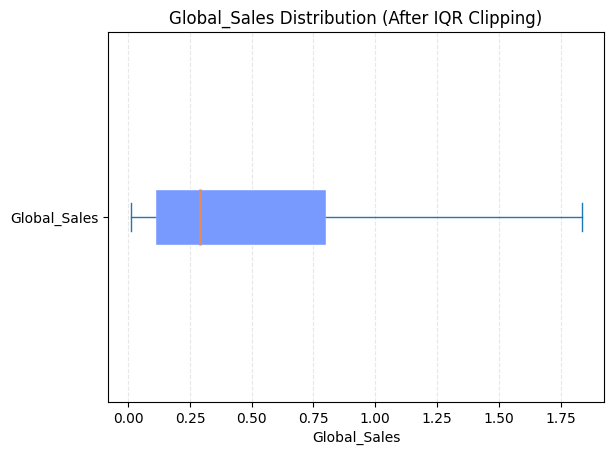

In [23]:


# ---- IQR CLIPPING ----
Q1 = df_clip['Global_Sales'].quantile(0.25)
Q3 = df_clip['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clip['Global_Sales'] = df_clip['Global_Sales'].clip(lower=lower, upper=upper)

# ---- PLOT AFTER CLIPPING ----
df_clip['Global_Sales'].plot(
    kind='box',
    title='Global_Sales Distribution (After IQR Clipping)',
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='#789AFF', color="#FFFFFF"),
    medianprops=dict(color='#EA8958', linewidth=2),
    flierprops=dict(marker='o', markersize=6,
                    markerfacecolor='#41D0A8',
                    markeredgecolor='#41D0A8')
)

plt.xlabel('Global_Sales')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

##Now Applying feature Transformation

#Transforming Critic score

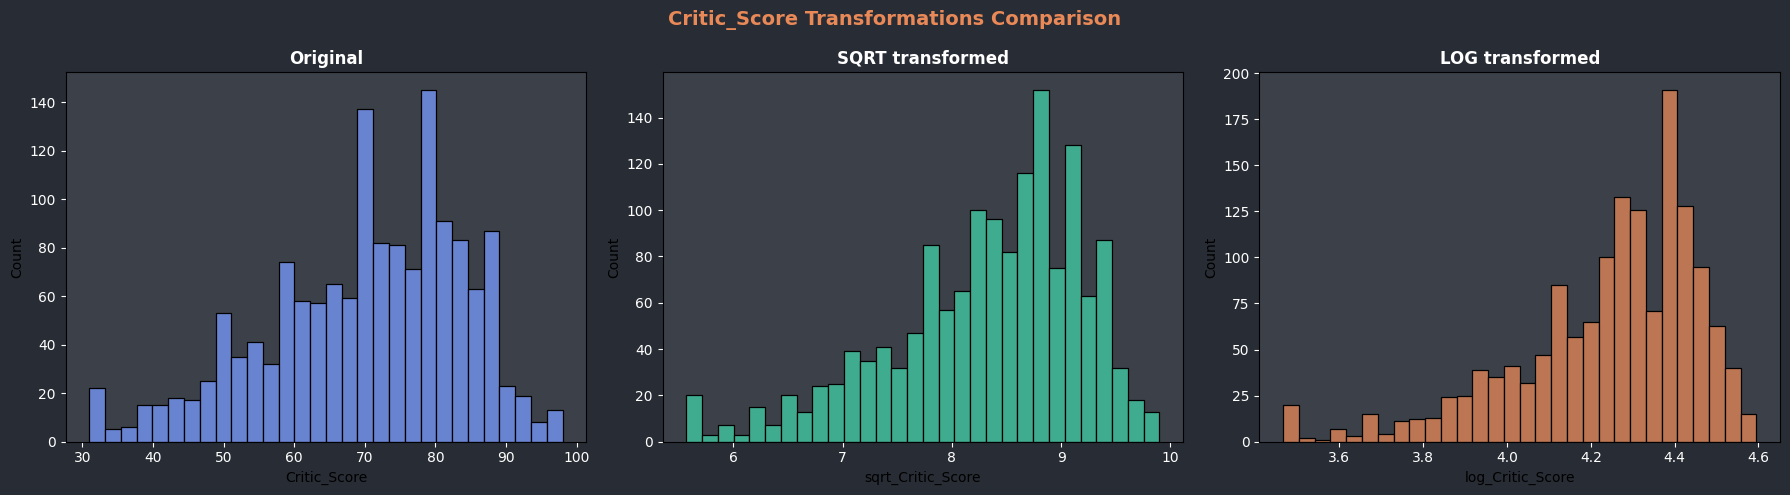

In [24]:
df_clip["sqrt_Critic_Score"] = np.sqrt(df_clip["Critic_Score"])
df_clip["log_Critic_Score"]  = np.log1p(df_clip["Critic_Score"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip["Critic_Score"], ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip["sqrt_Critic_Score"], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip["log_Critic_Score"], ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')

plt.suptitle('Critic_Score Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#The original is the least skewed so we go with it  and drop the rest

In [25]:
df_clip.drop(columns = ['sqrt_Critic_Score','log_Critic_Score'],inplace=True , axis = 1)

##Transforming Critic count

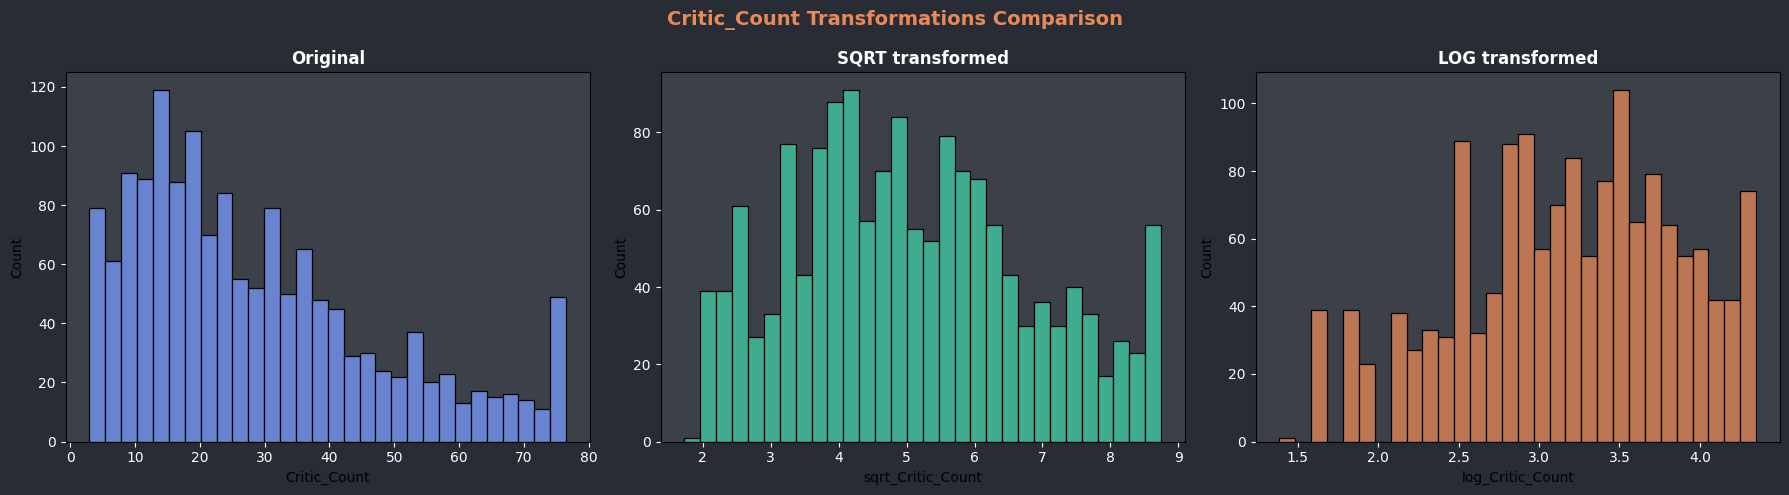

In [26]:
df_clip["sqrt_Critic_Count"] = np.sqrt(df_clip["Critic_Count"])
df_clip["log_Critic_Count"]  = np.log1p(df_clip["Critic_Count"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip["Critic_Count"], ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip["sqrt_Critic_Count"], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip["log_Critic_Count"], ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')

plt.suptitle('Critic_Count Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##Log transformed is the least skewed so we go with it

In [27]:
df_clip.drop(columns = ['sqrt_Critic_Count','Critic_Count'],inplace=True , axis = 1)

##Transforming User Count

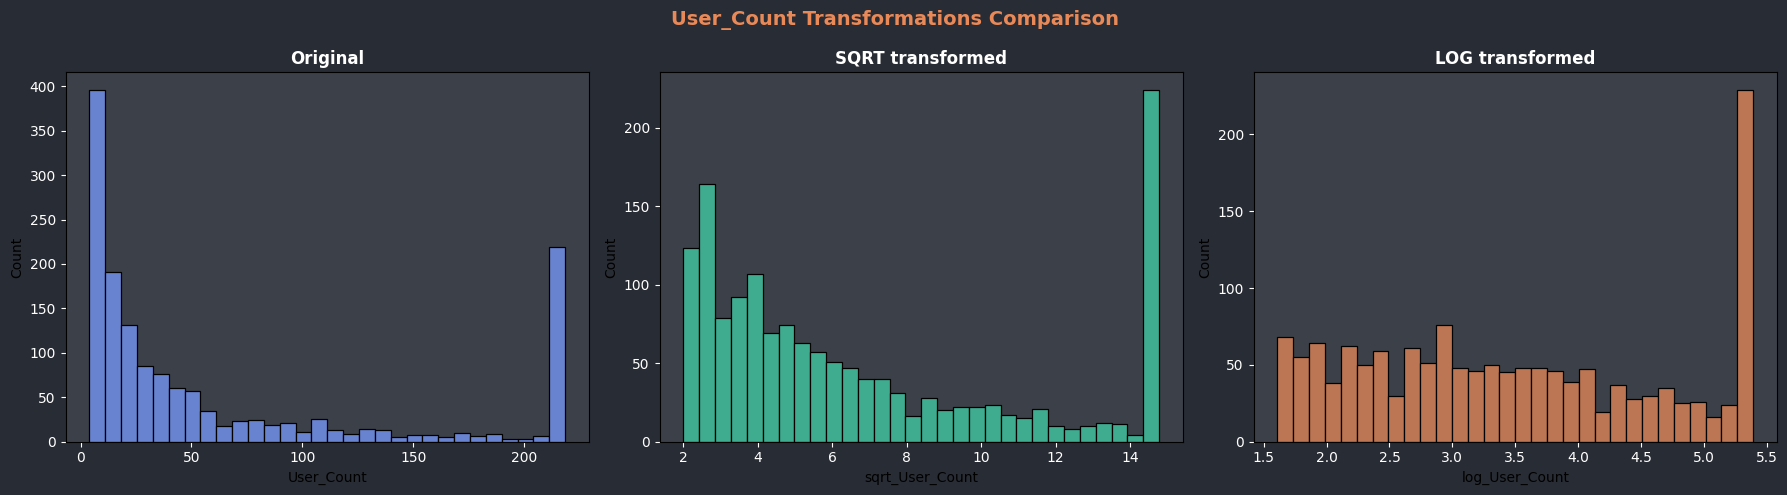

In [28]:
df_clip["sqrt_User_Count"] = np.sqrt(df_clip["User_Count"])
df_clip["log_User_Count"]  = np.log1p(df_clip["User_Count"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip["User_Count"], ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip["sqrt_User_Count"], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip["log_User_Count"], ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')

plt.suptitle('User_Count Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##Also log transformed is the least skewed so we go with it

In [29]:
df_clip.drop(columns = ['sqrt_User_Count','User_Count'],inplace=True , axis = 1)

##Transforming Global Sales

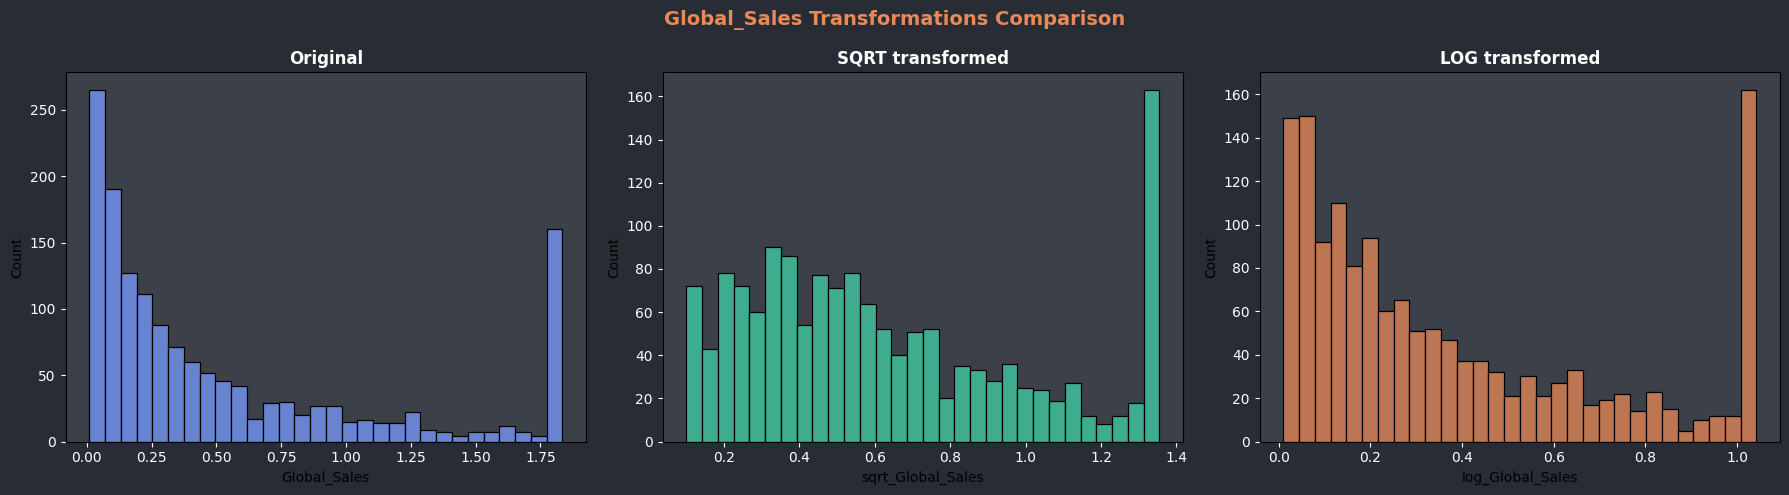

In [30]:
df_clip["sqrt_Global_Sales"] = np.sqrt(df_clip["Global_Sales"])
df_clip["log_Global_Sales"]  = np.log1p(df_clip["Global_Sales"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip["Global_Sales"], ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip["sqrt_Global_Sales"], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip["log_Global_Sales"], ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')

plt.suptitle('Global_Sales Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##Sqrt is the least skewed so we drop the rest

In [31]:
df_clip.drop(columns = ['Global_Sales','log_Global_Sales'],inplace=True , axis = 1)

##Transforming Game Age

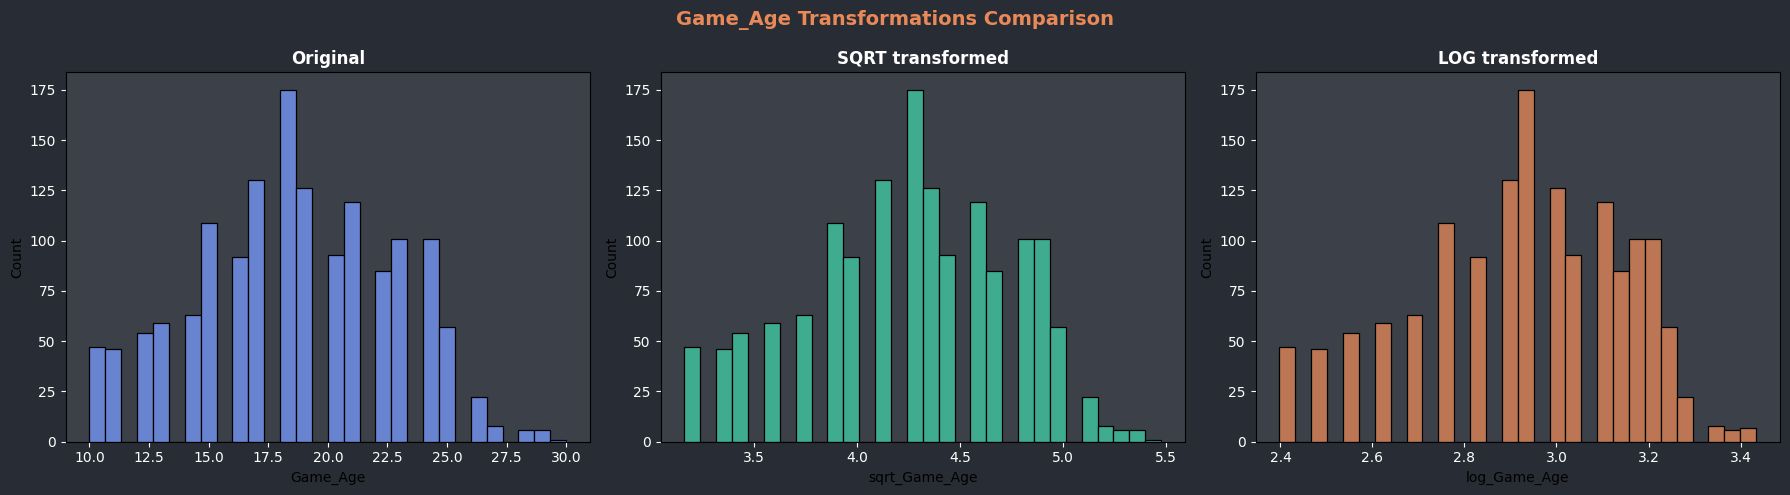

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clip["sqrt_Game_Age"] = np.sqrt(df_clip["Game_Age"])
df_clip["log_Game_Age"]  = np.log1p(df_clip["Game_Age"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.set_facecolor('#282C34')

sns.histplot(df_clip["Game_Age"], ax=axes[0], color='#789AFF', bins=30)
sns.histplot(df_clip["sqrt_Game_Age"], ax=axes[1], color='#41D0A8', bins=30)
sns.histplot(df_clip["log_Game_Age"], ax=axes[2], color='#EA8958', bins=30)

axes[0].set_title('Original', color='white', fontsize=12, fontweight='bold')
axes[1].set_title('SQRT transformed', color='white', fontsize=12, fontweight='bold')
axes[2].set_title('LOG transformed', color='white', fontsize=12, fontweight='bold')

for ax in axes:
    ax.set_facecolor('#3C4048')
    ax.tick_params(colors='white')

plt.suptitle('Game_Age Transformations Comparison',
             color='#EA8958', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#The original is great so we stay with it

In [33]:
df_clip.drop(columns = ['sqrt_Game_Age','log_Game_Age'],inplace=True , axis = 1)

##Applying descriptive graphs to visualize relation between Features


##What kind of games does my dataset mostly contain



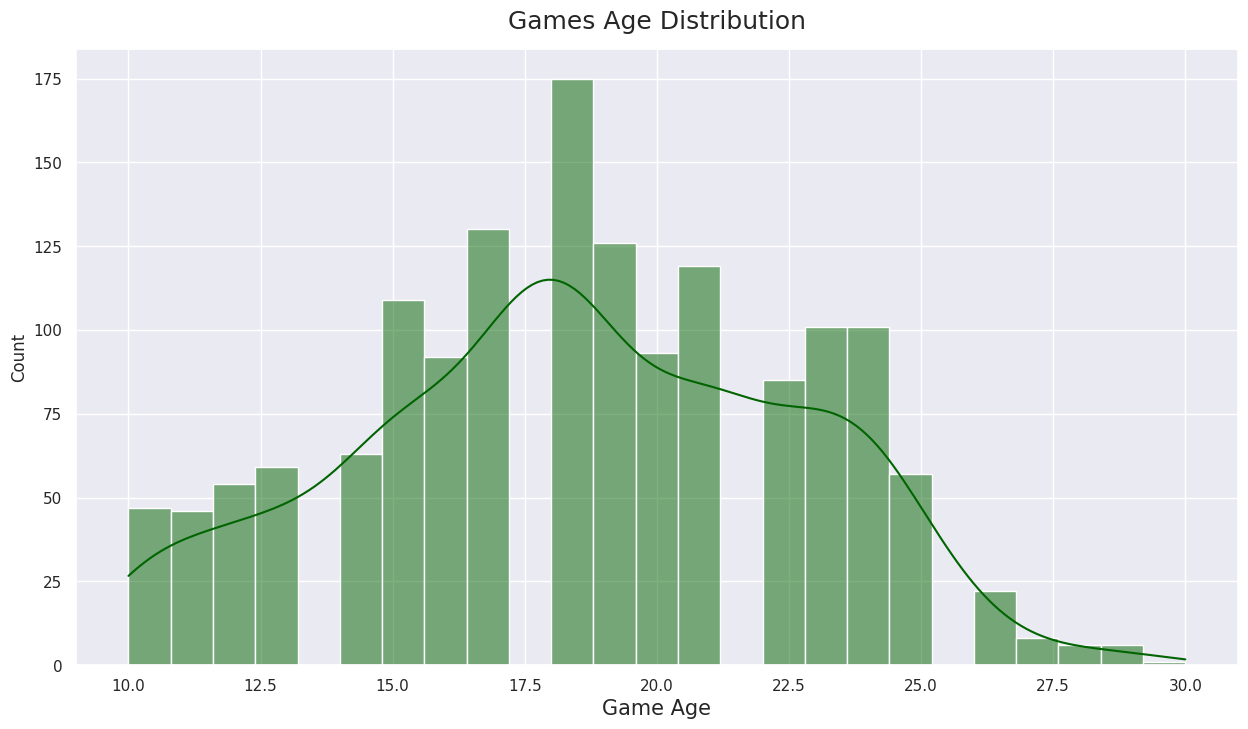

In [34]:


sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(15, 8))

sns.histplot(
    data=df,
    x="Game_Age",
    color="darkgreen",
    kde=True,
    bins=25,
    ax=ax
)

ax.set_title("Games Age Distribution", fontsize=18, y=1.02)
ax.set_xlabel("Game Age", fontsize=15)

plt.show()

##Plotting Global sales histogram

<Axes: xlabel='sqrt_Global_Sales', ylabel='Count'>

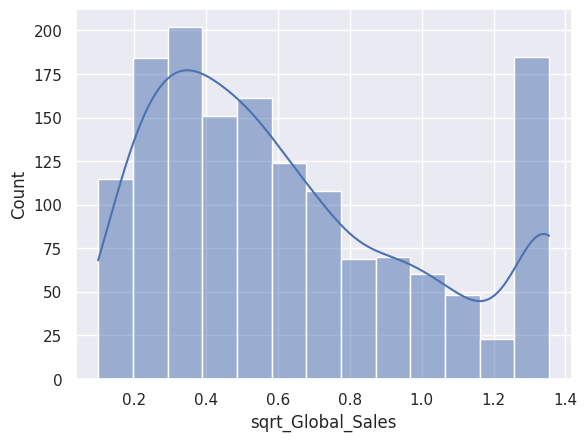

In [35]:
sns.histplot(df_clip["sqrt_Global_Sales"], bins="auto", kde=True)


##Plotting critic scores Vs global sales to see critic influence on sales

<Axes: xlabel='Critic_Score', ylabel='sqrt_Global_Sales'>

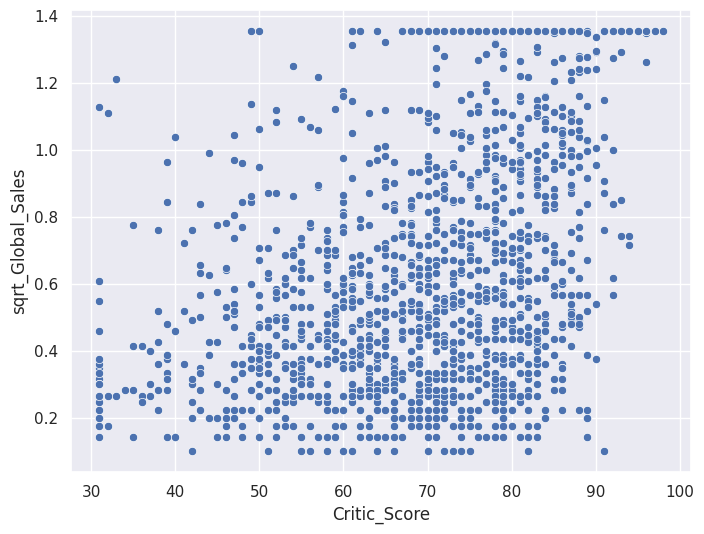

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clip,
    x="Critic_Score",
    y="sqrt_Global_Sales"
)



##Part 2: Standardizing data and training the model

##Spliting data into test and target

In [37]:
genre_platform_cols = [
    col for col in df_clip.columns
    if col.startswith('Genre_') or col.startswith('Platform_')
]

X = df_clip[['User_Score', 'Game_Age', 'log_User_Count', 'sqrt_Global_Sales'] + genre_platform_cols]
y = df_clip['Critic_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#Testing the model

In [38]:


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

print("=== Linear Regression ===")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

=== Linear Regression ===
Train R2: 0.5327238939943897
Test R2: 0.5996731996365785
Train RMSE: 9.593849041263436
Test RMSE: 8.73671561992289


##Trying to optimize using RIDGE

In [39]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

print("=== Ridge Regression ===")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

=== Ridge Regression ===
Train R2: 0.53272293119362
Test R2: 0.5996074792712223
Train RMSE: 9.5938589250991
Test RMSE: 8.737432729767448


#We are getting the exact value we got from the regular model lets try lasso

In [40]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_train_pred = lasso.predict(X_train_scaled)
y_test_pred = lasso.predict(X_test_scaled)

print("=== Lasso Regression ===")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

=== Lasso Regression ===
Train R2: 0.5309385965871656
Test R2: 0.6029388492298405
Train RMSE: 9.61215892794909
Test RMSE: 8.70100794865642


#Slightly higher result lets try Single regression and compare

---



In [41]:


# Features and target
X = df_clip[['User_Score']]
y = df_clip['Critic_Score']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
slr = LinearRegression()
slr.fit(X_train_scaled, y_train)

# Predictions
y_pred = slr.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

R2 Score: 0.41913066664542054
RMSE: 10.523981871807129


##A very bad result

##Visualizing the line

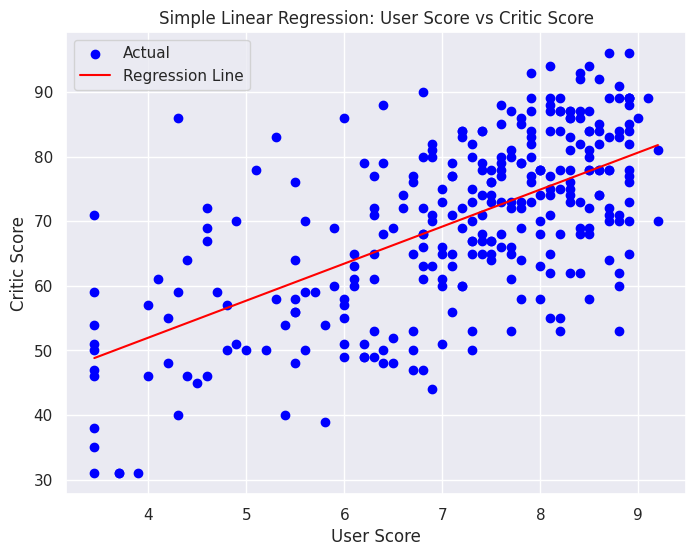

In [42]:

plt.figure(figsize=(8,6))

# scatter of actual values
plt.scatter(X_test, y_test, color="blue", label="Actual")

# regression line (use sorted X for clean line)
sorted_idx = X_test.values.flatten().argsort()

plt.plot(
    X_test.values.flatten()[sorted_idx],
    y_pred[sorted_idx],
    color="red",
    label="Regression Line"
)

plt.xlabel("User Score")
plt.ylabel("Critic Score")
plt.title("Simple Linear Regression: User Score vs Critic Score")
plt.legend()

plt.show()

##Addign visualizations to see how the Target data is scattered


/tmp/ipykernel_3536/1191439531.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend(title="Model Type", loc="lower right")


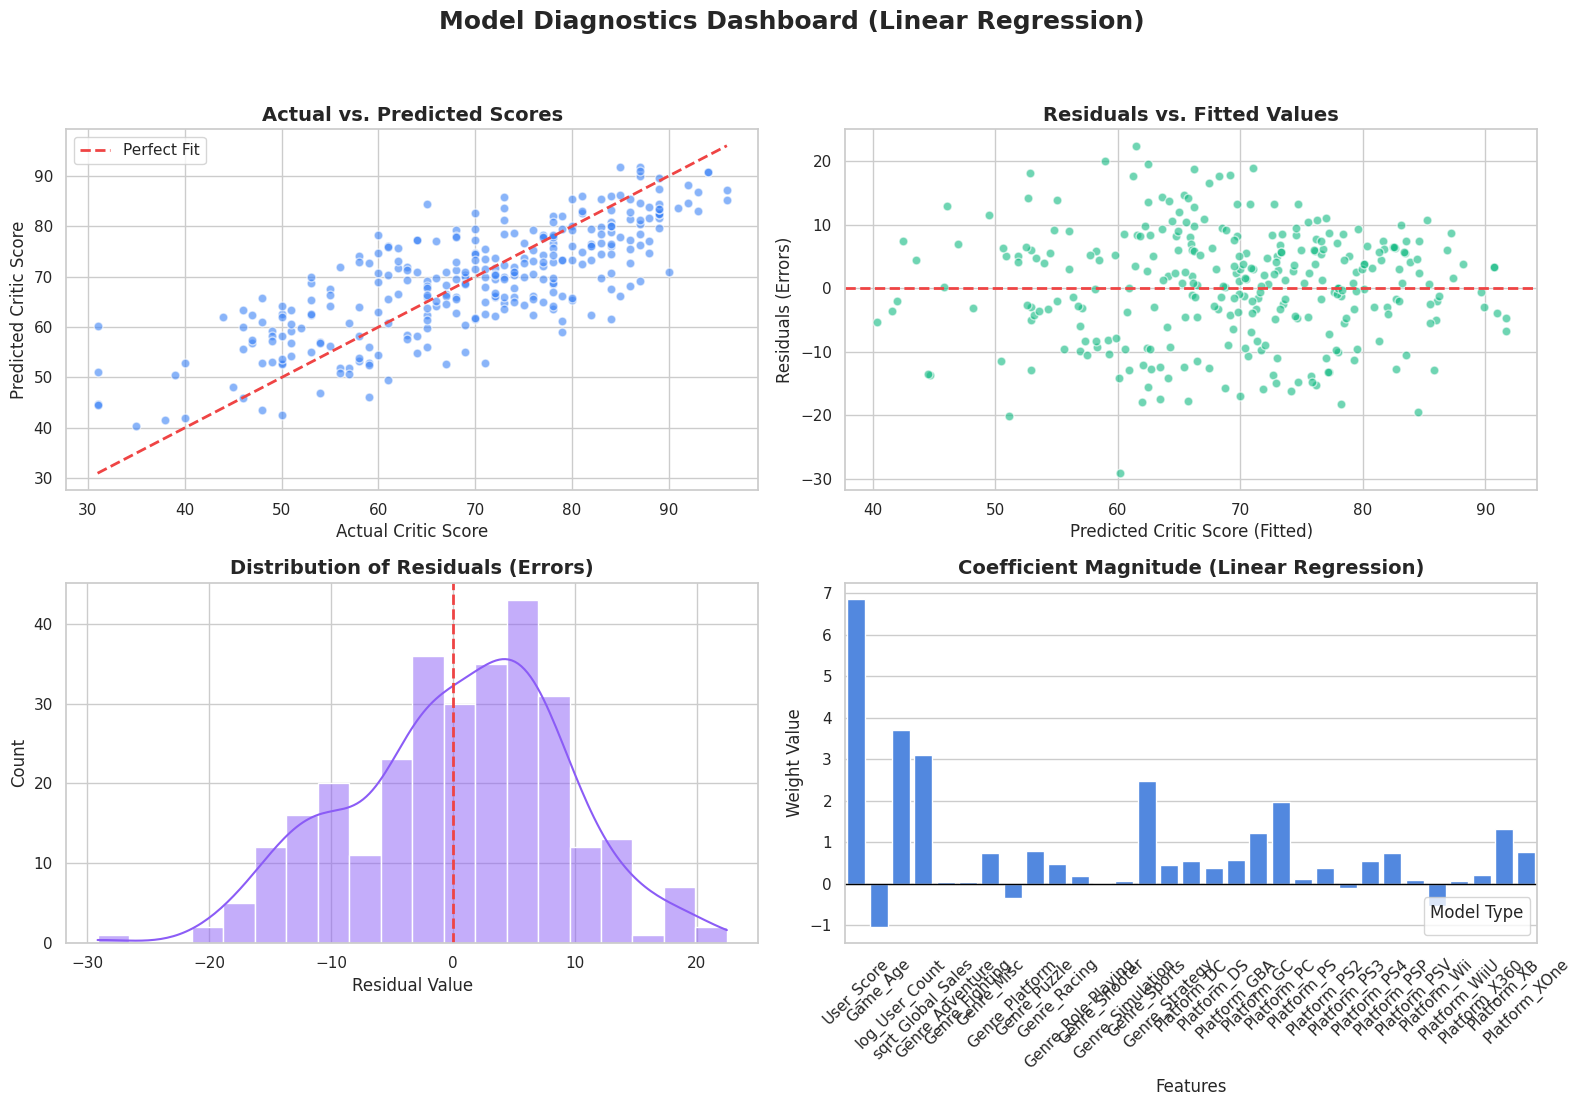

In [43]:


# --- Data Preparation (Ensuring consistent multi-feature data for evaluation) ---
genre_platform_cols = [
    col for col in df_clip.columns
    if col.startswith('Genre_') or col.startswith('Platform_')
]

# Redefine X and y to use the multi-feature set for consistent evaluation
X = df_clip[['User_Score', 'Game_Age', 'log_User_Count', 'sqrt_Global_Sales'] + genre_platform_cols]
y = df_clip['Critic_Score']

# Redo the train/test split and scaling for the multi-feature X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-instantiate and train models to ensure they use the correct multi-feature data
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

# --- Original Code Modified for Linear Regression Focus ---

# Fix: Define the 'models' dictionary using previously trained models
# Assumes 'lr', 'ridge', and 'lasso' model objects are available in the kernel scope from prior cell executions.
models = {
    "Linear Regression": lr,
    "Ridge Regression (L2)": ridge,
    "Lasso Regression": lasso
}

# Set the chosen model to Linear Regression
chosen_model_name = "Linear Regression"
chosen_model = models[chosen_model_name]

# Generate predictions for the test set using our scaled features
y_pred_test = chosen_model.predict(X_test_scaled)
residuals = y_test - y_pred_test

# Set style for clean aesthetics
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Model Diagnostics Dashboard ({chosen_model_name})', fontsize=18, fontweight='bold', y=0.95)

# ─── PLOT 1: Actual vs Predicted ──────────────────────────────────────────
axes[0, 0].scatter(y_test, y_pred_test, color='#3B82F6', alpha=0.6, edgecolors='w', s=40)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], color='#EF4444', lw=2, linestyle='--', label='Perfect Fit')
axes[0, 0].set_title('Actual vs. Predicted Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Actual Critic Score')
axes[0, 0].set_ylabel('Predicted Critic Score')
axes[0, 0].legend()

# ─── PLOT 2: Residuals vs Fitted (Predicted) ──────────────────────────────
axes[0, 1].scatter(y_pred_test, residuals, color='#10B981', alpha=0.6, edgecolors='w', s=40)
axes[0, 1].axhline(y=0, color='#EF4444', lw=2, linestyle='--')
axes[0, 1].set_title('Residuals vs. Fitted Values', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Critic Score (Fitted)')
axes[0, 1].set_ylabel('Residuals (Errors)')

# ─── PLOT 3: Distribution of Residuals ────────────────────────────────────
sns.histplot(residuals, kde=True, color='#8B5CF6', ax=axes[1, 0], bins=20)
axes[1, 0].axvline(x=0, color='#EF4444', lw=2, linestyle='--')
axes[1, 0].set_title('Distribution of Residuals (Errors)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Residual Value')
axes[1, 0].set_ylabel('Count')

# ─── PLOT 4: Coefficient Magnitude for Linear Regression ────────────────
# Put coefficients into a dataframe for easy plotting
coef_data = []
# Use X.columns from the multi-feature X for correct feature names
for feat, coef in zip(X.columns, chosen_model.coef_):
    coef_data.append({"Feature": feat, "Coefficient Value": coef})
df_coef = pd.DataFrame(coef_data)

sns.barplot(data=df_coef, x="Feature", y="Coefficient Value", color="#3B82F6", ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='black', lw=1)
axes[1, 1].set_title(f'Coefficient Magnitude ({chosen_model_name})', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Features')
axes[1, 1].set_ylabel('Weight Value')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title="Model Type", loc="lower right")

# Final layouts
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

#Part3: Polynomial regression

In [44]:


# ── 1. Features and Target ────────────────────────────────────────────────────

# FIX: Added double brackets to select multiple columns correctly
X = df_clip[['User_Score', 'Game_Age', 'log_User_Count', 'sqrt_Global_Sales']]
y = df_clip['Critic_Score']

# ── 2. Train/Test Split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6
)

# ── 3. Feature Scaling (Must happen BEFORE Polynomial Features) ───────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. Polynomial Features (Change degree here to see metrics change!) ────────
DEGREE = 2  # try changing this to 3 or 4
poly = PolynomialFeatures(degree=DEGREE, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)


# ── 5. Train Model ────────────────────────────────────────────────────────────
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# ── 6. Predictions ────────────────────────────────────────────────────────────
y_train_pred = poly_reg.predict(X_train_poly)
y_test_pred  = poly_reg.predict(X_test_poly)

# ── 7. Evaluation ─────────────────────────────────────────────────────────────
print(f"\nPolynomial Regression (degree {DEGREE}):")
print(f"  Training R²  : {r2_score(y_train, y_train_pred):.4f}")
print(f"  Testing R²   : {r2_score(y_test,  y_test_pred):.4f}")
print(f"  Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"  Testing RMSE : {np.sqrt(mean_squared_error(y_test,  y_test_pred)):.4f}")


Polynomial Regression (degree 2):
  Training R²  : 0.4856
  Testing R²   : 0.5797
  Training RMSE: 9.9891
  Testing RMSE : 9.2270


##Gradient descent

Training samples : 1200
Features (deg 2) : 15

Training Polynomial Regression — Batch Gradient Descent
  Epoch     0 — Loss: 2419.439051
  Epoch  1000 — Loss: 92.936207
  Epoch  2000 — Loss: 54.522986
  Epoch  3000 — Loss: 48.350967
  Epoch  4000 — Loss: 47.230202
  Epoch  5000 — Loss: 47.011696
  Epoch  6000 — Loss: 46.966692
  Epoch  7000 — Loss: 46.956999

✅ Converged at epoch 7961

Results — Polynomial Regression (Batch Gradient Descent)
  Learning Rate : 0.005
  Total Epochs  : 7962
  Final Loss    : 46.954875

  Training R²  : 0.5008
  Testing R²   : 0.5159
  Training RMSE: 9.6907
  Testing RMSE : 10.4486


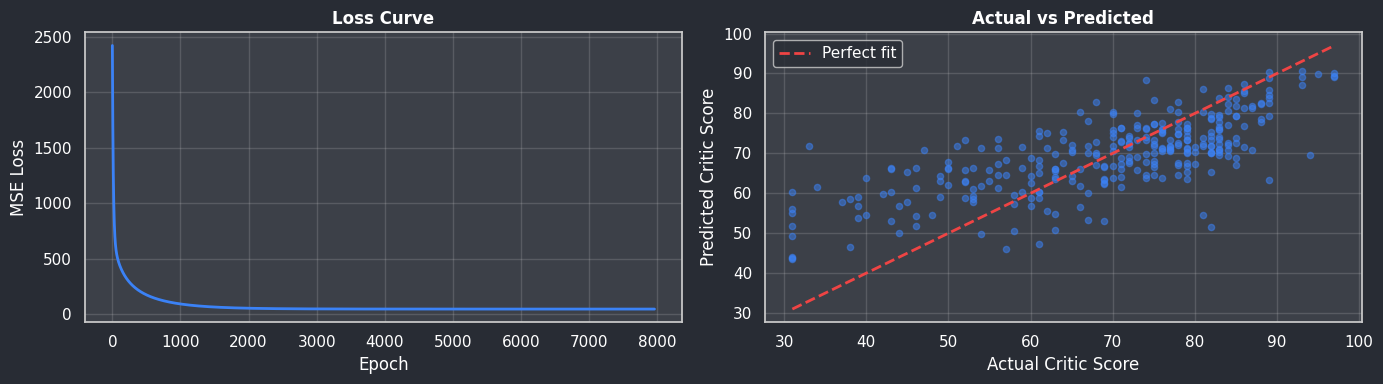

In [45]:

# ── Features and Target ───────────────────────────────────────────────────────
X = df_clip[['User_Score', 'Game_Age', 'log_User_Count', 'sqrt_Global_Sales']]
y = df_clip['Critic_Score'].values

# ── Train/Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Scale X ───────────────────────────────────────────────────────────────────
scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Polynomial Features ───────────────────────────────────────────────────────
poly         = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly  = poly.transform(X_test_scaled)

n_samples, n_features = X_train_poly.shape
print(f"Training samples : {n_samples}")
print(f"Features (deg 2) : {n_features}")

# ══════════════════════════════════════════════════════════════════════
#  1. HYPOTHESIS FUNCTION  →  h(x) = X · W
# ══════════════════════════════════════════════════════════════════════
def hypothesis(X, W):
    """
    Compute predictions: h(x) = X · W
    X : (n_samples, n_features)
    W : (n_features,)
    returns: (n_samples,)
    """
    return X @ W

# ══════════════════════════════════════════════════════════════════════
#  2. LOSS FUNCTION  →  J(W) = (1/2m) * Σ(h(xᵢ) - yᵢ)²
# ══════════════════════════════════════════════════════════════════════
def loss_function(X, y, W):
    """
    Mean Squared Error loss: J(W) = (1/2m) * Σ(h(xᵢ) - yᵢ)²
    Divided by 2 to simplify the gradient derivative
    """
    m    = len(y)
    pred = hypothesis(X, W)
    return (1 / (2 * m)) * np.sum((pred - y) ** 2)

# ══════════════════════════════════════════════════════════════════════
#  3. GRADIENT DESCENT  →  W := W - α * (1/m) * Xᵀ · (h(x) - y)
# ══════════════════════════════════════════════════════════════════════
def gradient_descent(X, y, learning_rate=0.005, epochs=10000):
    """
    Batch Gradient Descent — uses ALL samples every iteration

    Parameters:
        X             : polynomial feature matrix (n_samples, n_features)
        y             : target values (n_samples,)
        learning_rate : step size α
        epochs        : max number of iterations

    Returns:
        W             : optimized weights
        loss_history  : loss at each epoch
    """
    m, n         = X.shape
    W            = np.zeros(n)
    loss_history = []

    for epoch in range(epochs):

        # ── Hypothesis ────────────────────────────────────────────────
        y_pred = hypothesis(X, W)

        # ── Error ─────────────────────────────────────────────────────
        error  = y_pred - y

        # ── Gradient: ∂J/∂W = (1/m) * Xᵀ · error ────────────────────
        gradient = (1 / m) * (X.T @ error)

        # ── Check for explosion before updating ───────────────────────
        if np.any(np.isnan(gradient)) or np.any(np.isinf(gradient)):
            print(f"⚠️  Gradient exploded at epoch {epoch} — stopping early")
            break

        # ── Update weights: W := W - α * gradient ────────────────────
        W = W - learning_rate * gradient

        # ── Track loss ────────────────────────────────────────────────
        loss = loss_function(X, y, W)
        loss_history.append(loss)

        # ── Print progress every 1000 epochs ──────────────────────────
        if epoch % 1000 == 0:
            print(f"  Epoch {epoch:>5} — Loss: {loss:.6f}")

        # ── Auto stop when converged ───────────────────────────────────
        if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < 1e-6:
            print(f"\n✅ Converged at epoch {epoch}")
            break

    return W, loss_history

# ══════════════════════════════════════════════════════════════════════
#  4. TRAIN
# ══════════════════════════════════════════════════════════════════════
print("\nTraining Polynomial Regression — Batch Gradient Descent")
print("=" * 55)

W_optimized, loss_history = gradient_descent(
    X_train_poly,
    y_train,
    learning_rate=0.005,
    epochs=10000
)

# ══════════════════════════════════════════════════════════════════════
#  5. EVALUATE
# ══════════════════════════════════════════════════════════════════════
y_train_pred = hypothesis(X_train_poly, W_optimized)
y_test_pred  = hypothesis(X_test_poly,  W_optimized)

train_r2   = r2_score(y_train, y_train_pred)
test_r2    = r2_score(y_test,  y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_test_pred))

print("\n" + "=" * 55)
print("Results — Polynomial Regression (Batch Gradient Descent)")
print("=" * 55)
print(f"  Learning Rate : 0.005")
print(f"  Total Epochs  : {len(loss_history)}")
print(f"  Final Loss    : {loss_history[-1]:.6f}")
print(f"\n  Training R²  : {train_r2:.4f}")
print(f"  Testing R²   : {test_r2:.4f}")
print(f"  Training RMSE: {train_rmse:.4f}")
print(f"  Testing RMSE : {test_rmse:.4f}")

# ══════════════════════════════════════════════════════════════════════
#  6. PLOTS
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.set_facecolor('#282C34')

# Loss Curve
axes[0].set_facecolor('#3C4048')
axes[0].plot(loss_history, color='#3B82F6', lw=2)
axes[0].set_title('Loss Curve', color='white', fontweight='bold')
axes[0].set_xlabel('Epoch', color='white')
axes[0].set_ylabel('MSE Loss', color='white')
axes[0].tick_params(colors='white')
axes[0].grid(alpha=0.2)

# Actual vs Predicted
axes[1].set_facecolor('#3C4048')
axes[1].scatter(y_test, y_test_pred, color='#3B82F6', alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#EF4444', lw=2, linestyle='--', label='Perfect fit')
axes[1].set_title('Actual vs Predicted', color='white', fontweight='bold')
axes[1].set_xlabel('Actual Critic Score', color='white')
axes[1].set_ylabel('Predicted Critic Score', color='white')
axes[1].tick_params(colors='white')
axes[1].legend(labelcolor='white', facecolor='#282C34')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

##Dashboard

In [46]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ── 1. FEATURES AND TARGET EXTRACTION ─────────────────────────────────────────
X = df_clip[['User_Score', 'Game_Age', 'log_User_Count', 'sqrt_Global_Sales']]
y = df_clip['Critic_Score'].values

# ── 2. TRAIN/TEST SPLIT ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=6
)

# ── 3. FEATURE SCALING ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 4. MLR MODEL ──────────────────────────────────────────────────────────────
mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

# ── 5. STATS FUNCTION ─────────────────────────────────────────────────────────
def calculate_regression_stats(y_true, y_pred, features_count):
    residuals = y_true - y_pred
    mse = mean_squared_error(y_true, y_pred)
    counts, bin_edges = np.histogram(residuals, bins=15)
    bin_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(counts))]
    sample_size = min(len(y_true), 150)
    idx = np.linspace(0, len(y_true) - 1, sample_size, dtype=int)
    sort_idx = np.argsort(y_true[idx])
    final_indices = idx[sort_idx]
    return {
        "r2": float(round(r2_score(y_true, y_pred), 4)),
        "mse": float(round(mse, 2)),
        "rmse": float(round(np.sqrt(mse), 2)),
        "max_error": float(round(np.max(np.abs(residuals)), 2)),
        "features": int(features_count),
        "actuals": [round(float(y_true[i]), 2) for i in final_indices],
        "preds": [round(float(y_pred[i]), 2) for i in final_indices],
        "residuals": [round(float(residuals[i]), 2) for i in final_indices],
        "res_bin_centers": [round(float(x), 2) for x in bin_centers],
        "res_bin_counts": [int(c) for c in counts]
    }

# ── 6. COMPUTE STATS FOR MLR AND POLY DEGREES 2-5 ─────────────────────────────
stats = {
    "MLR": calculate_regression_stats(y_test, y_pred_mlr, X_train.shape[1])
}

for deg in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly  = poly.transform(X_test_scaled)
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    y_pred_poly = poly_reg.predict(X_test_poly)
    stats[f"POLY_{deg}"] = calculate_regression_stats(y_test, y_pred_poly, X_train_poly.shape[1])

stats_json = json.dumps(stats)

# ── 7. BATMAN ARKHAM ORIGINS THEMED HTML INTERACTIVE DASHBOARD ────────────────
html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Cinzel:wght@600;700;800&family=Orbitron:wght@400;500;600;700&family=Share+Tech+Mono&display=swap" rel="stylesheet">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<style>
  *{{box-sizing:border-box;margin:0;padding:0}}
  :root{{
    --bg:#020408;
    --panel:rgba(8, 12, 20, 0.88);
    --panel2:rgba(6, 9, 18, 0.92);
    --ice:#4fc3f7;
    --ice-dim:#29b6f6;
    --ice-glow:rgba(79,195,247,0.15);
    --orange:#ff6d00;
    --orange-dim:#ff9100;
    --orange-glow:rgba(255,109,0,0.15);
    --bat-gray:#37474f;
    --text:#e3f2fd;
    --muted:#546e7a;
    --border:#1a2332;
    --accent:var(--ice);
  }}

  body{{
    font-family:'Share Tech Mono',monospace;
    background: url('https://wallpapers.com/images/hd/gotham-city-92tlpzp2qufjk1is.jpg') no-repeat center center fixed;
    background-size: cover;
    color:var(--text);
    padding:24px;
    min-height:100vh;
    position:relative;
    overflow-x:hidden;
  }}

  /* Split overlay: blue left, orange right */
  body::before{{
    content:"";
    position:fixed;
    top:0;left:0;right:0;bottom:0;
    background:
      linear-gradient(90deg, rgba(79,195,247,0.06) 0%, rgba(79,195,247,0.06) 49%, transparent 49%, transparent 51%, rgba(255,109,0,0.06) 51%, rgba(255,109,0,0.06) 100%),
      radial-gradient(circle at center, rgba(2, 4, 8, 0.4) 0%, rgba(2, 4, 8, 0.92) 100%);
    pointer-events:none;
    z-index:0;
  }}

  /* Vertical divider line */
  body::after{{
    content:"";
    position:fixed;
    top:0;
    left:50%;
    width:1px;
    height:100%;
    background:linear-gradient(180deg, transparent 0%, rgba(79,195,247,0.4) 20%, rgba(150,150,150,0.2) 50%, rgba(255,109,0,0.4) 80%, transparent 100%);
    pointer-events:none;
    z-index:1;
  }}

  /* Theme modes */
  body.mlr-mode {{ --accent: var(--ice); }}
  body.poly-mode {{ --accent: var(--orange); }}

  .bat-clipart-bg {{
    position: absolute;
    top: 15px;
    left: 0;
    width: 100%;
    height: 60px;
    pointer-events: none;
    opacity: 0.12;
    z-index: 1;
    background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 30' fill='%234fc3f7'%3E%3Cpath d='M50 2c-2 4-6 5-11 3 2 5 0 9-5 9 3 2 4 6 1 10 4-2 8-1 10 3 1-4 3-5 5-8 2 3 4 4 5 8 2-4 6-5 10-3-3-4-2-8 1-10-5 0-7-4-5-9-5 2-9 1-11-3z'/%3E%3C/svg%3E");
    background-size: 180px 45px;
    background-repeat: repeat-x;
    filter: drop-shadow(0 0 8px rgba(79,195,247,0.4));
  }}

  .header-wrapper {{
    position: relative;
    width: 100%;
    min-height: 450px;
    margin-bottom: 16px;
    z-index: 2;
  }}

  .evidence-photo{{
    position: absolute;
    top: 45px;
    width: 320px;
    background:#060a10;
    border:2px solid #1a2332;
    padding:10px;
    box-shadow:0 15px 45px rgba(0,0,0,0.95), 0 0 25px rgba(79,195,247,0.06);
    transition:all 0.4s ease;
    z-index:10;
  }}

  .batman-photo{{
    left: 15px;
    transform:rotate(-1deg);
    border-color: rgba(79,195,247,0.3);
    box-shadow:0 15px 45px rgba(0,0,0,0.95), 0 0 35px rgba(79,195,247,0.15);
  }}

  .deathstroke-photo{{
    right: 15px;
    transform:rotate(1deg);
    border-color: rgba(255,109,0,0.3);
    box-shadow:0 15px 45px rgba(0,0,0,0.95), 0 0 35px rgba(255,109,0,0.15);
  }}

  .evidence-photo:hover{{
    transform: scale(1.03) translateY(-4px);
    z-index: 25;
  }}

  .batman-photo:hover {{
    border-color:rgba(79,195,247,0.6);
    box-shadow:0 15px 45px rgba(0,0,0,0.95), 0 0 50px rgba(79,195,247,0.3);
  }}

  .deathstroke-photo:hover {{
    border-color:rgba(255,109,0,0.6);
    box-shadow:0 15px 45px rgba(0,0,0,0.95), 0 0 50px rgba(255,109,0,0.3);
  }}

  .evidence-photo::before{{
    content:attr(data-label);
    position:absolute;
    top:-11px;
    left:24px;
    background:#020408;
    color:var(--ice);
    font-size:11px;
    letter-spacing:2px;
    text-transform:uppercase;
    padding:2px 12px;
    border:1px solid #1a2332;
  }}

  .deathstroke-photo::before {{
    left: auto;
    right: 24px;
    color: var(--orange);
  }}

  .evidence-photo img{{ width:100%; height:280px; object-fit:cover; display:block; }}

  .photo-caption{{
    font-family:'Orbitron',sans-serif;
    font-size:11px;
    font-weight: 600;
    color:var(--text);
    text-align:center;
    margin-top:10px;
    letter-spacing:2px;
    text-transform:uppercase;
    border-top:1px dashed #1a2332;
    padding-top:8px;
  }}

  .logo-wrap{{
    text-align:center;
    padding-top: 20px;
    margin: 0 auto;
    max-width: calc(100% - 680px);
    position:relative;
    z-index:20;
  }}

  .logo-img{{
    width: 280px;
    height: auto;
    object-fit: contain;
    filter: drop-shadow(0 0 20px rgba(79,195,247,0.6));
  }}

  .gcpd-stamp{{
    font-family:'Orbitron',sans-serif;
    font-size:11px;
    color:var(--orange);
    border:1px solid var(--orange);
    padding:4px 18px;
    display:inline-block;
    letter-spacing:5px;
    text-transform:uppercase;
    margin-top:15px;
    background: rgba(8,12,20,0.9);
    clip-path:polygon(3% 0, 100% 0, 97% 100%, 0% 100%);
  }}

  h1{{
    font-family:'Cinzel',serif;
    font-size:24px;
    color:var(--ice);
    letter-spacing:3px;
    margin-top: 14px;
    text-shadow: 0 0 10px rgba(0,0,0,0.9);
  }}

  .subtitle{{
    font-size:12px;
    color:var(--text);
    text-shadow: 0 1px 4px rgba(0,0,0,0.9);
    letter-spacing:2px;
    text-transform:uppercase;
  }}

  .toggle-wrap{{
    display:flex;
    margin:28px auto;
    background:var(--panel);
    border:1px solid var(--border);
    backdrop-filter: blur(4px);
    width:fit-content;
    position:relative;
    z-index:30;
  }}

  .toggle-btn{{
    padding:12px 24px;
    border:none;
    cursor:pointer;
    font-family:'Orbitron',sans-serif;
    font-size:11px;
    font-weight:600;
    text-transform:uppercase;
    letter-spacing:2px;
    transition:all .3s;
    color:var(--muted);
    background:transparent;
    border-right:1px solid var(--border);
  }}

  .toggle-btn:last-child{{border-right:none;}}

  .toggle-btn.mlr-btn.active{{
    background:linear-gradient(180deg, rgba(79,195,247,0.2) 0%, rgba(79,195,247,0.05) 100%);
    color:var(--ice);
    border-bottom:2px solid var(--ice);
    box-shadow: 0 0 15px rgba(79,195,247,0.2);
  }}

  .toggle-btn.poly-btn.active{{
    background:linear-gradient(180deg, rgba(255,109,0,0.2) 0%, rgba(255,109,0,0.05) 100%);
    color:var(--orange);
    border-bottom:2px solid var(--orange);
    box-shadow: 0 0 15px rgba(255,109,0,0.2);
  }}

  .toggle-btn.cmp-btn.active{{
    background:linear-gradient(90deg, rgba(79,195,247,0.15) 0%, rgba(79,195,247,0.15) 50%, rgba(255,109,0,0.15) 50%, rgba(255,109,0,0.15) 100%);
    color:var(--text);
    border-bottom:2px solid var(--text);
  }}

  /* Degree selector */
  .degree-wrap{{
    display:flex;
    align-items:center;
    justify-content:center;
    gap:16px;
    margin:0 auto 24px;
    padding:12px 24px;
    background:var(--panel);
    border:1px solid rgba(255,109,0,0.3);
    backdrop-filter: blur(4px);
    width:fit-content;
    position:relative;
    z-index:30;
    box-shadow: 0 0 20px rgba(255,109,0,0.1);
  }}

  .degree-label{{
    font-family:'Orbitron',sans-serif;
    font-size:11px;
    color:var(--orange);
    letter-spacing:3px;
    text-transform:uppercase;
    text-shadow: 0 0 8px rgba(255,109,0,0.4);
  }}

  .degree-buttons{{
    display:flex;
    gap:8px;
  }}

  .degree-btn{{
    padding:8px 16px;
    border:1px solid var(--border);
    background:transparent;
    color:var(--muted);
    font-family:'Orbitron',sans-serif;
    font-size:10px;
    font-weight:600;
    letter-spacing:2px;
    cursor:pointer;
    transition:all 0.3s;
  }}

  .degree-btn:hover{{
    border-color:var(--orange-dim);
    color:var(--orange-dim);
  }}

  .degree-btn.active{{
    background:linear-gradient(180deg, rgba(255,109,0,0.25) 0%, rgba(255,109,0,0.08) 100%);
    color:var(--orange);
    border-color:var(--orange);
    box-shadow: 0 0 12px rgba(255,109,0,0.3);
  }}

  .metrics-grid{{
    display:grid;
    grid-template-columns:repeat(5,1fr);
    gap:14px;
    margin-bottom:24px;
    z-index: 2;
    position: relative;
  }}

  .metric-card{{
    background:var(--panel);
    border:1px solid var(--border);
    backdrop-filter: blur(4px);
    padding:20px 14px;
    position:relative;
    overflow:hidden;
    box-shadow: 0 10px 25px rgba(0,0,0,0.6);
    transition: all 0.4s ease;
  }}

  .metric-card::before{{
    content:'';
    position:absolute;
    top:0;left:0;right:0;height:2px;
    background:var(--accent);
    box-shadow:0 0 10px var(--accent);
    transition: all 0.4s ease;
  }}

  .metric-val{{
    font-size:28px;
    font-weight:700;
    font-family:'Orbitron',sans-serif;
    color:var(--accent);
    text-shadow:0 0 12px var(--accent);
    margin-bottom:4px;
    transition: all 0.4s ease;
  }}

  .metric-lbl{{
    font-size:10px;
    color:var(--muted);
    text-transform:uppercase;
    letter-spacing:2px;
  }}

  .charts-grid{{
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:16px;
    margin-bottom:24px;
    z-index: 2;
    position: relative;
  }}

  .chart-card{{
    background:var(--panel);
    border:1px solid var(--border);
    backdrop-filter: blur(4px);
    padding:20px;
    position:relative;
    box-shadow: 0 10px 25px rgba(0,0,0,0.6);
  }}

  .chart-title{{
    font-size:12px;
    font-weight:700;
    margin-bottom:16px;
    text-transform:uppercase;
    letter-spacing:2px;
    font-family:'Orbitron',sans-serif;
    color: var(--accent);
    transition: color 0.4s ease;
  }}

  .report-wrap{{
    background:var(--panel);
    border:1px solid var(--border);
    backdrop-filter: blur(4px);
    padding:20px;
    position:relative;
    box-shadow: 0 10px 25px rgba(0,0,0,0.6);
    z-index: 2;
  }}

  .report-wrap::before{{
    content:'[ANALYST CRITERION]';
    position:absolute;
    top:-1px;right:24px;
    background:linear-gradient(90deg, var(--ice), var(--orange));
    color:#020408;
    font-size:9px;
    padding:3px 10px;
    letter-spacing:3px;
    font-weight:700;
  }}

  .compare-row{{
    display:flex;
    align-items:center;
    gap:14px;
    padding:16px 0;
    border-bottom:1px solid var(--border);
  }}

  .compare-lbl{{
    font-size:12px;
    color:var(--text);
    width:160px;
    text-transform:uppercase;
    letter-spacing:2px;
    font-family:'Orbitron',sans-serif;
  }}

  .compare-bars{{ flex:1; display:flex; flex-direction:column; gap:8px; }}
  .cbar-wrap{{ display:flex; align-items:center; gap:10px; }}
  .cbar-name{{ font-size:11px; width:60px; font-weight:700; }}

  .cbar{{
    flex:1; height:10px; background:var(--panel2);
    overflow:hidden; border:1px solid var(--border);
  }}

  .cbar-fill{{ height:100%; transition:width 1s ease; }}
  .cbar-val{{ font-size:12px; font-family:'Orbitron',sans-serif; width:100px; text-align:right; }}

  .win-badge {{
    font-size: 9px;
    padding: 2px 6px;
    margin-left: 6px;
    letter-spacing: 1px;
    font-weight: 700;
  }}

  .win-badge.ice {{
    background: rgba(79,195,247,0.2);
    color: var(--ice);
    border: 1px solid var(--ice);
  }}

  .win-badge.orange {{
    background: rgba(255,109,0,0.2);
    color: var(--orange);
    border: 1px solid var(--orange);
  }}
</style>
</head>
<body class="mlr-mode">

<div class="bat-clipart-bg"></div>

<div class="header-wrapper">
    <div class="evidence-photo batman-photo" data-label="Standard System">
        <img src="https://cdn.europosters.eu/image/1300/167589.jpg" alt="Batman Poster Art">
        <div class="photo-caption">Architecture: Standard MLR</div>
    </div>

    <div class="logo-wrap">
        <img src="https://www.pngall.com/wp-content/uploads/3/Batman-Arkham-Origins-Logo-PNG-Free-Download.png" class="logo-img" alt="Batman Logo">
        <br>
        <div class="gcpd-stamp">GCPD Tactical Terminal</div>
        <h1>Regression Framework Assessment</h1>
        <p class="subtitle">Continuous Critic Estimation · OLS vs Poly Expand · {len(y_test)} validation targets</p>
    </div>

    <div class="evidence-photo deathstroke-photo" data-label="Expanded Boundary">
        <img src="https://cdnb.artstation.com/p/assets/images/images/000/000/229/large/deathstroke1.jpg?1400170387" alt="Deathstroke Portfolio Art">
        <div class="photo-caption">Architecture: Polynomial Expansion</div>
    </div>
</div>

<div class="toggle-wrap">
  <button class="toggle-btn mlr-btn active" onclick="switchModel('MLR',this)">Linear (MLR)</button>
  <button class="toggle-btn poly-btn" onclick="switchModel('POLY',this)">Polynomial</button>
  <button class="toggle-btn cmp-btn" onclick="switchModel('CMP',this)">Telemetry Contrast</button>
</div>

<div id="degree-selector" class="degree-wrap" style="display:none">
  <div class="degree-label">Polynomial Degree</div>
  <div class="degree-buttons">
    <button class="degree-btn active" onclick="switchDegree(2, this)">DEG 2</button>
    <button class="degree-btn" onclick="switchDegree(3, this)">DEG 3</button>
    <button class="degree-btn" onclick="switchDegree(4, this)">DEG 4</button>
    <button class="degree-btn" onclick="switchDegree(5, this)">DEG 5</button>
  </div>
</div>

<div id="view-single">
  <div class="metrics-grid">
    <div class="metric-card">
      <div class="metric-val" id="m-r2">—</div>
      <div class="metric-lbl">R² Variance Score</div>
    </div>
    <div class="metric-card">
      <div class="metric-val" id="m-mse">—</div>
      <div class="metric-lbl">Mean Squared Error</div>
    </div>
    <div class="metric-card">
      <div class="metric-val" id="m-rmse">—</div>
      <div class="metric-lbl">Root MSE Accuracy</div>
    </div>
    <div class="metric-card">
      <div class="metric-val" id="m-max">—</div>
      <div class="metric-lbl">Max Residual Drop</div>
    </div>
    <div class="metric-card">
      <div class="metric-val" id="m-feat">—</div>
      <div class="metric-lbl">Total Feature Vectors</div>
    </div>
  </div>

  <div class="charts-grid">
    <div class="chart-card">
      <div class="chart-title" id="title-left">Chart Alpha</div>
      <canvas id="pvChart" height="150"></canvas>
    </div>
    <div class="chart-card">
      <div class="chart-title" id="title-right">Chart Beta</div>
      <canvas id="resChart" height="150"></canvas>
    </div>
  </div>
</div>

<div id="view-compare" style="display:none">
  <div class="report-wrap">
    <div class="chart-title" style="color:var(--text)">Analytical Contrast Array</div>
    <div id="compare-content"></div>
  </div>
</div>

<script>
const STATS = {stats_json};
let charts = {{}};
let currentModel = 'MLR';
let currentDegree = 2;

function switchModel(m, btn) {{
  document.querySelectorAll('.toggle-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');

  currentModel = m;

  if(m === 'CMP') {{
    document.getElementById('view-single').style.display = 'none';
    document.getElementById('view-compare').style.display = 'block';
    document.getElementById('degree-selector').style.display = 'flex';
    renderCompare();
  }} else {{
    document.getElementById('view-single').style.display = 'block';
    document.getElementById('view-compare').style.display = 'none';

    if (m === 'POLY') {{
      document.getElementById('degree-selector').style.display = 'flex';
      document.body.classList.remove('mlr-mode');
      document.body.classList.add('poly-mode');
    }} else {{
      document.getElementById('degree-selector').style.display = 'none';
      document.body.classList.remove('poly-mode');
      document.body.classList.add('mlr-mode');
    }}

    renderSingle(m);
  }}
}}

function switchDegree(deg, btn) {{
  document.querySelectorAll('.degree-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
  currentDegree = deg;

  if (currentModel === 'POLY') {{
    renderSingle('POLY');
  }} else if (currentModel === 'CMP') {{
    renderCompare();
  }}
}}

function renderSingle(m) {{
  const key = m === 'MLR' ? 'MLR' : `POLY_${{currentDegree}}`;
  const s = STATS[key];

  document.getElementById('m-r2').textContent = s.r2.toFixed(4);
  document.getElementById('m-mse').textContent = s.mse;
  document.getElementById('m-rmse').textContent = s.rmse;
  document.getElementById('m-max').textContent = s.max_error;
  document.getElementById('m-feat').textContent = s.features;

  if (m === 'MLR') {{
    document.getElementById('title-left').textContent = "Actual vs. Predicted Scores (Perfect Fit Reference Axis)";
    document.getElementById('title-right').textContent = "Distribution of Residual Errors (Normality Bell Curve)";
    renderMLRPVChart(s);
    renderMLRResidualsChart(s);
  }} else {{
    document.getElementById('title-left').textContent = `Model Prediction Curve Tracking Index (Poly Deg ${{currentDegree}})`;
    document.getElementById('title-right').textContent = "Residual Wave Signal Variance Mapping (Error Delta Frequency)";
    renderPolyCurveChart(s);
    renderPolyWaveChart(s);
  }}
}}

function renderMLRPVChart(s) {{
  if(charts.pv) charts.pv.destroy();
  const ctx = document.getElementById('pvChart').getContext('2d');
  const scatterPoints = s.actuals.map((act, i) => ({{ x: act, y: s.preds[i] }}));
  const minVal = Math.min(...s.actuals, ...s.preds) - 5;
  const maxVal = Math.max(...s.actuals, ...s.preds) + 5;

  charts.pv = new Chart(ctx, {{
    data: {{
      datasets: [
        {{
          type: 'scatter',
          label: 'Validation Test Sample Coordinates',
          data: scatterPoints,
          backgroundColor: '#4fc3f7',
          pointRadius: 4,
          borderColor: 'rgba(2,4,8,0.6)',
          borderWidth: 1
        }},
        {{
          type: 'line',
          label: 'Ideal Identity Vector (Perfect Fit Line)',
          data: [{{x: minVal, y: minVal}}, {{x: maxVal, y: maxVal}}],
          borderColor: '#EF4444',
          borderWidth: 2,
          borderDash: [5, 5],
          pointRadius: 0,
          fill: false
        }}
      ]
    }},
    options: {{
      responsive: true,
      plugins: {{ legend: {{ labels: {{ color: '#546e7a', font: {{ family: 'Share Tech Mono' }} }} }} }},
      scales: {{
        x: {{ type: 'linear', position: 'bottom', grid: {{ color: '#0d1b2a' }}, ticks: {{ color: '#546e7a' }}, title: {{ display: true, text: 'Actual Scores', color: '#546e7a' }} }},
        y: {{ grid: {{ color: '#0d1b2a' }}, ticks: {{ color: '#546e7a' }}, title: {{ display: true, text: 'Predicted Scores', color: '#546e7a' }} }}
      }}
    }}
  }});
}}

function renderMLRResidualsChart(s) {{
  if(charts.res) charts.res.destroy();
  const ctx = document.getElementById('resChart').getContext('2d');

  charts.res = new Chart(ctx, {{
    data: {{
      labels: s.res_bin_centers,
      datasets: [
        {{
          type: 'bar',
          label: 'Error Frequency (Histogram Bins)',
          data: s.res_bin_counts,
          backgroundColor: 'rgba(79,195,247,0.35)',
          borderColor: '#4fc3f7',
          borderWidth: 1,
          barPercentage: 1.0,
          categoryPercentage: 1.0
        }},
        {{
          type: 'line',
          label: 'KDE Density Curve Approximation',
          data: s.res_bin_counts,
          borderColor: '#4fc3f7',
          borderWidth: 2.5,
          pointRadius: 0,
          tension: 0.4,
          fill: false
        }}
      ]
    }},
    options: {{
      responsive: true,
      plugins: {{ legend: {{ labels: {{ color: '#546e7a', font: {{ family: 'Share Tech Mono' }} }} }} }},
      scales: {{
        x: {{ grid: {{ color: '#0d1b2a' }}, ticks: {{ color: '#546e7a' }}, title: {{ display: true, text: 'Residual Margin (Errors)', color: '#546e7a' }} }},
        y: {{ grid: {{ color: '#0d1b2a' }}, ticks: {{ color: '#546e7a' }}, title: {{ display: true, text: 'Frequency Delta', color: '#546e7a' }} }}
      }}
    }}
  }});
}}

function renderPolyCurveChart(s) {{
  if(charts.pv) charts.pv.destroy();
  const ctx = document.getElementById('pvChart').getContext('2d');

  charts.pv = new Chart(ctx, {{
    type: 'line',
    data: {{
      labels: Array.from({{length: s.actuals.length}}, (_, i) => i),
      datasets: [
        {{
          label: 'Actual Target Values (Sorted Trend)',
          data: s.actuals,
          borderColor: '#546e7a',
          borderWidth: 1.5,
          pointRadius: 2,
          fill: false,
          tension: 0.1
        }},
        {{
          label: `Polynomial Regression Curve Fit (Deg ${{currentDegree}})`,
          data: s.preds,
          borderColor: '#ff6d00',
          borderWidth: 2.5,
          pointRadius: 0,
          fill: false,
          tension: 0.3
        }}
      ]
    }},
    options: {{
      responsive: true,
      plugins: {{ legend: {{ labels: {{ color: '#546e7a', font: {{ family: 'Share Tech Mono' }} }} }} }},
      scales: {{
        x: {{ display: false, grid: {{ color: '#0d1b2a' }} }},
        y: {{ grid: {{ color: '#0d1b2a' }}, ticks: {{ color: '#546e7a' }}, title: {{ display: true, text: 'Score Space Range', color: '#546e7a' }} }}
      }}
    }}
  }});
}}

function renderPolyWaveChart(s) {{
  if(charts.res) charts.res.destroy();
  const ctx = document.getElementById('resChart').getContext('2d');

  charts.res = new Chart(ctx, {{
    type: 'line',
    data: {{
      labels: Array.from({{length: s.residuals.length}}, (_, i) => i),
      datasets: [
        {{
          label: 'Residual Error Deviation Path',
          data: s.residuals,
          borderColor: '#ff9100',
          backgroundColor: 'rgba(255,109,0,0.06)',
          borderWidth: 2,
          pointRadius: 1.5,
          fill: true,
          tension: 0.2
        }}
      ]
    }},
    options: {{
      responsive: true,
      plugins: {{ legend: {{ labels: {{ color: '#546e7a', font: {{ family: 'Share Tech Mono' }} }} }} }},
      scales: {{
        x: {{ display: false, grid: {{ color: '#0d1b2a' }} }},
        y: {{
          grid: {{ color: '#0d1b2a' }},
          ticks: {{ color: '#546e7a' }},
          title: {{ display: true, text: 'Residual Value Deviation', color: '#546e7a' }}
        }}
      }}
    }}
  }});
}}

function renderCompare() {{
  const metrics = ['r2', 'mse', 'rmse', 'max_error'];
  const labels = ['R² Coefficient', 'Mean Squared Error', 'Root MSE Accuracy', 'Max Boundary Error'];

  const mlr = STATS['MLR'];
  const poly = STATS[`POLY_${{currentDegree}}`];

  document.getElementById('compare-content').innerHTML = metrics.map((m, i) => {{
    const mv = mlr[m];
    const pv = poly[m];

    const polyWins = m === 'r2' ? (pv >= mv) : (pv <= mv);
    const maxScale = Math.max(mv, pv, 1);
    const mPct = (mv / maxScale) * 100;
    const pPct = (pv / maxScale) * 100;

    return `
    <div class="compare-row">
      <div class="compare-lbl">${{labels[i]}}</div>
      <div class="compare-bars">
        <div class="cbar-wrap">
          <div class="cbar-name" style="color:var(--ice)">MLR</div>
          <div class="cbar"><div class="cbar-fill" style="width:${{mPct}}%;background:var(--ice)"></div></div>
          <div class="cbar-val" style="color:var(--ice)">${{mv}}${{!polyWins ? '<span class="win-badge ice">WIN</span>' : ''}}</div>
        </div>
        <div class="cbar-wrap">
          <div class="cbar-name" style="color:var(--orange)">POLY ${{currentDegree}}</div>
          <div class="cbar"><div class="cbar-fill" style="width:${{pPct}}%;background:var(--orange)"></div></div>
          <div class="cbar-val" style="color:var(--orange)">${{pv}}${{polyWins ? '<span class="win-badge orange">WIN</span>' : ''}}</div>
        </div>
      </div>
    </div>`;
  }}).join('');
}}

renderSingle('MLR');
</script>
</body>
</html>
"""

display(HTML(html))